# 1.000 veces menos hollín... y las estelas siguen ahí

Los motores de nueva generación eliminan el 99,9% de las partículas de hollín. ¿Por qué las estelas de los aviones siguen formándose como si nada?

---

📄 **Paper:** Voigt, C. et al. *Substantial aircraft contrail formation at low soot emission levels*. **Nature** (2026)  
🔗 **DOI:** [10.1038/s41586-026-10286-0](https://doi.org/10.1038/s41586-026-10286-0)  
[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-04-04-estelas-avion-motor-bajo-hollin/notebook.ipynb)  
🔬 **Notebook:** [Ciencia a Mordiscos — El Lab](https://cienciaamordiscos.com/papers/2026-04-04-estelas-avion-motor-bajo-hollin/notebook.html)

## El problema invisible del tráfico aéreo

Las estelas de condensación (contrails) de los aviones no son solo líneas decorativas en el cielo. Se transforman en nubes cirrus artificiales que atrapan calor — y su efecto sobre el clima es comparable al de todo el CO₂ acumulado que la aviación ha emitido desde sus inicios.

La industria apostó por motores lean-burn (combustión pobre) para reducir las emisiones de hollín. La lógica era sencilla: menos hollín = menos semillas para cristales de hielo = menos estelas. Un equipo del DLR (la agencia espacial alemana) persiguió un Airbus A321neo con motores LEAP-1A — los más modernos del mercado — para medir qué pasa realmente.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
EI_NV_RICH = 1.0e15       # Hollín rich-burn, Jet A-1 (kg⁻¹)
EI_NV_LEAN = 1.0e12       # Hollín lean-burn, Jet A-1 (kg⁻¹)
EI_ICE_JETA1 = 1.6e15     # Cristales hielo lean-burn, Jet A-1 (kg⁻¹)
EI_ICE_HEFA = 0.5e15      # Cristales hielo lean-burn, HEFA-blend (kg⁻¹)
FUENTE = 'Fuente: Voigt et al. (2026), Nature | Datos: Zenodo (10.5281/zenodo.18830350)'

COLOR_JETA1 = '#2563EB'     # Azul CaM — Jet A-1 convencional
COLOR_HEFA = '#059669'      # Emerald — HEFA-blend (bajo azufre)
COLOR_SPK = '#D97706'       # Amber — HEFA-SPK (muy bajo azufre)
COLOR_ALERTA = '#DC2626'    # Rojo — puntos de medición / alertas
COLOR_GRIS = '#BBBBBB'      # Referencia

# ══════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import os, urllib.request

# Estilo CaM
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
plt.style.use(style_file)

# Cargar datos
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/papers/2026-04-04-estelas-avion-motor-bajo-hollin'
for fname in ['curvas_acm_combustibles.csv', 'curvas_acm_temperaturas.csv', 'mediciones_vuelo.csv']:
    local = f'datos/{fname}'
    if not os.path.exists(local):
        os.makedirs('datos', exist_ok=True)
        urllib.request.urlretrieve(f'{BASE}/datos/{fname}', local)

df_fuel = pd.read_csv('datos/curvas_acm_combustibles.csv')
df_temp = pd.read_csv('datos/curvas_acm_temperaturas.csv')
df_meas = pd.read_csv('datos/mediciones_vuelo.csv')

print(f"Curvas ACM (combustibles): {len(df_fuel)} puntos — {df_fuel['fuel'].nunique()} combustibles")
print(f"Curvas ACM (temperaturas): {len(df_temp)} puntos — {df_temp['fuel'].nunique()} combustibles × {df_temp['temp_k'].nunique()} temperaturas")
print(f"Mediciones in-flight: {len(df_meas)} registros")
print(f"\nCombustibles: Jet A-1 (192 ppmm S), HEFA-blend (75 ppmm S), HEFA-SPK (3,2 ppmm S)")

Curvas ACM (combustibles): 102 puntos — 3 combustibles
Curvas ACM (temperaturas): 204 puntos — 2 combustibles × 3 temperaturas
Mediciones in-flight: 5 registros

Combustibles: Jet A-1 (192 ppmm S), HEFA-blend (75 ppmm S), HEFA-SPK (3,2 ppmm S)


## Eliminaron el hollín. Las estelas no se enteraron.

Aquí está.

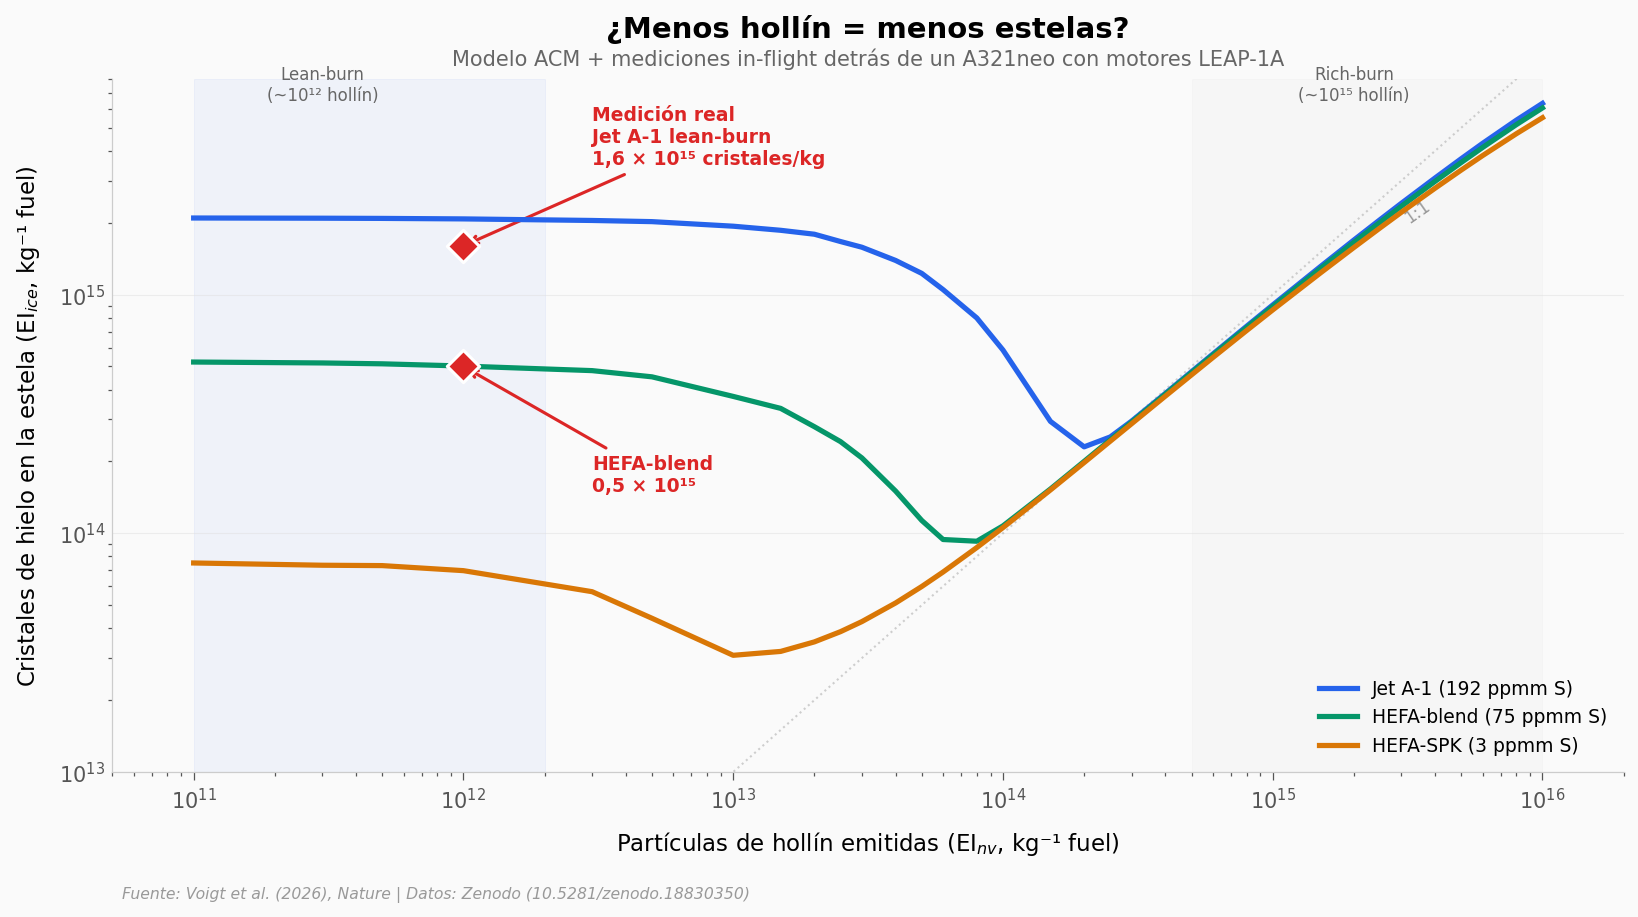

In [2]:
fig, ax = plt.subplots(figsize=(13, 6))

# Curvas ACM para 3 combustibles (modelo teórico)
for fuel, color, label in [
    ('Jet-A1_con2', COLOR_JETA1, 'Jet A-1 (192 ppmm S)'),
    ('HEFA_con2', COLOR_HEFA, 'HEFA-blend (75 ppmm S)'),
    ('HEFA', COLOR_SPK, 'HEFA-SPK (3 ppmm S)')
]:
    sub = df_fuel[df_fuel['fuel'] == fuel].sort_values('soot_ei_kg')
    ax.plot(sub['soot_ei_kg'], sub['ice_ei_kg'], color=color, linewidth=2.5, label=label, zorder=4)

# Puntos de medición reales
ax.scatter(EI_NV_LEAN, EI_ICE_JETA1, color=COLOR_ALERTA, s=120, zorder=6,
           edgecolors='white', linewidths=1.5, marker='D')
ax.annotate(f'Medición real\nJet A-1 lean-burn\n1,6 × 10¹⁵ cristales/kg',
            xy=(EI_NV_LEAN, EI_ICE_JETA1), xytext=(3e12, 3.5e15),
            fontsize=9, color=COLOR_ALERTA, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.5))

ax.scatter(EI_NV_LEAN, EI_ICE_HEFA, color=COLOR_ALERTA, s=120, zorder=6,
           edgecolors='white', linewidths=1.5, marker='D')
ax.annotate(f'HEFA-blend\n0,5 × 10¹⁵',
            xy=(EI_NV_LEAN, EI_ICE_HEFA), xytext=(3e12, 1.5e14),
            fontsize=9, color=COLOR_ALERTA, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.5))

# Línea 1:1
x_11 = np.logspace(11, 16, 100)
ax.plot(x_11, x_11, color=COLOR_GRIS, linewidth=1, linestyle=':', alpha=0.7, zorder=2)
ax.text(3e15, 2e15, '1:1', fontsize=8, color='#999999', rotation=35)

# Zonas de régimen
ax.axvspan(1e11, 2e12, alpha=0.05, color=COLOR_JETA1, zorder=1)
ax.text(3e11, 6.5e15, 'Lean-burn\n(~10¹² hollín)', fontsize=8, color='#666666', ha='center')
ax.axvspan(5e14, 1e16, alpha=0.05, color=COLOR_GRIS, zorder=1)
ax.text(2e15, 6.5e15, 'Rich-burn\n(~10¹⁵ hollín)', fontsize=8, color='#666666', ha='center')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Partículas de hollín emitidas (EI$_{nv}$, kg⁻¹ fuel)', fontsize=11)
ax.set_ylabel('Cristales de hielo en la estela (EI$_{ice}$, kg⁻¹ fuel)', fontsize=11)
ax.set_title('¿Menos hollín = menos estelas?', fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Modelo ACM + mediciones in-flight detrás de un A321neo con motores LEAP-1A',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlim(5e10, 2e16)
ax.set_ylim(1e13, 8e15)
ax.legend(fontsize=9, loc='lower right', framealpha=0.9)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/hero_hollin_vs_hielo.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que los datos nos cuentan

Miremos la zona izquierda — el régimen lean-burn. El hollín se desploma (eje X), pero los cristales de hielo (eje Y) apenas bajan para Jet A-1 convencional. Los diamantes rojos lo confirman: 1,6 × 10¹⁵ cristales por kilo de combustible, prácticamente lo mismo que con motores viejos.

La clave está en las curvas: cada combustible traza una "U". Al eliminar el hollín, los cristales de hielo **dejan de nuclearse sobre el hollín y pasan a nuclearse sobre partículas volátiles** — compuestos de azufre, orgánicos y vapores de aceite lubricante.

El combustible bajo en azufre (HEFA-blend, verde) produce 3,2× menos cristales. Y la versión ultra-pura (HEFA-SPK, ámbar) baja ~30× respecto al Jet A-1 — pero a costa de ser 100% biocombustible.

## La temperatura decide cuántos cristales se forman

Los motores no operan en el vacío. La temperatura ambiente a altitud de crucero varía entre 216 K y 220 K (−57 °C a −53 °C). ¿Cuánta diferencia hacen esos 4 grados?

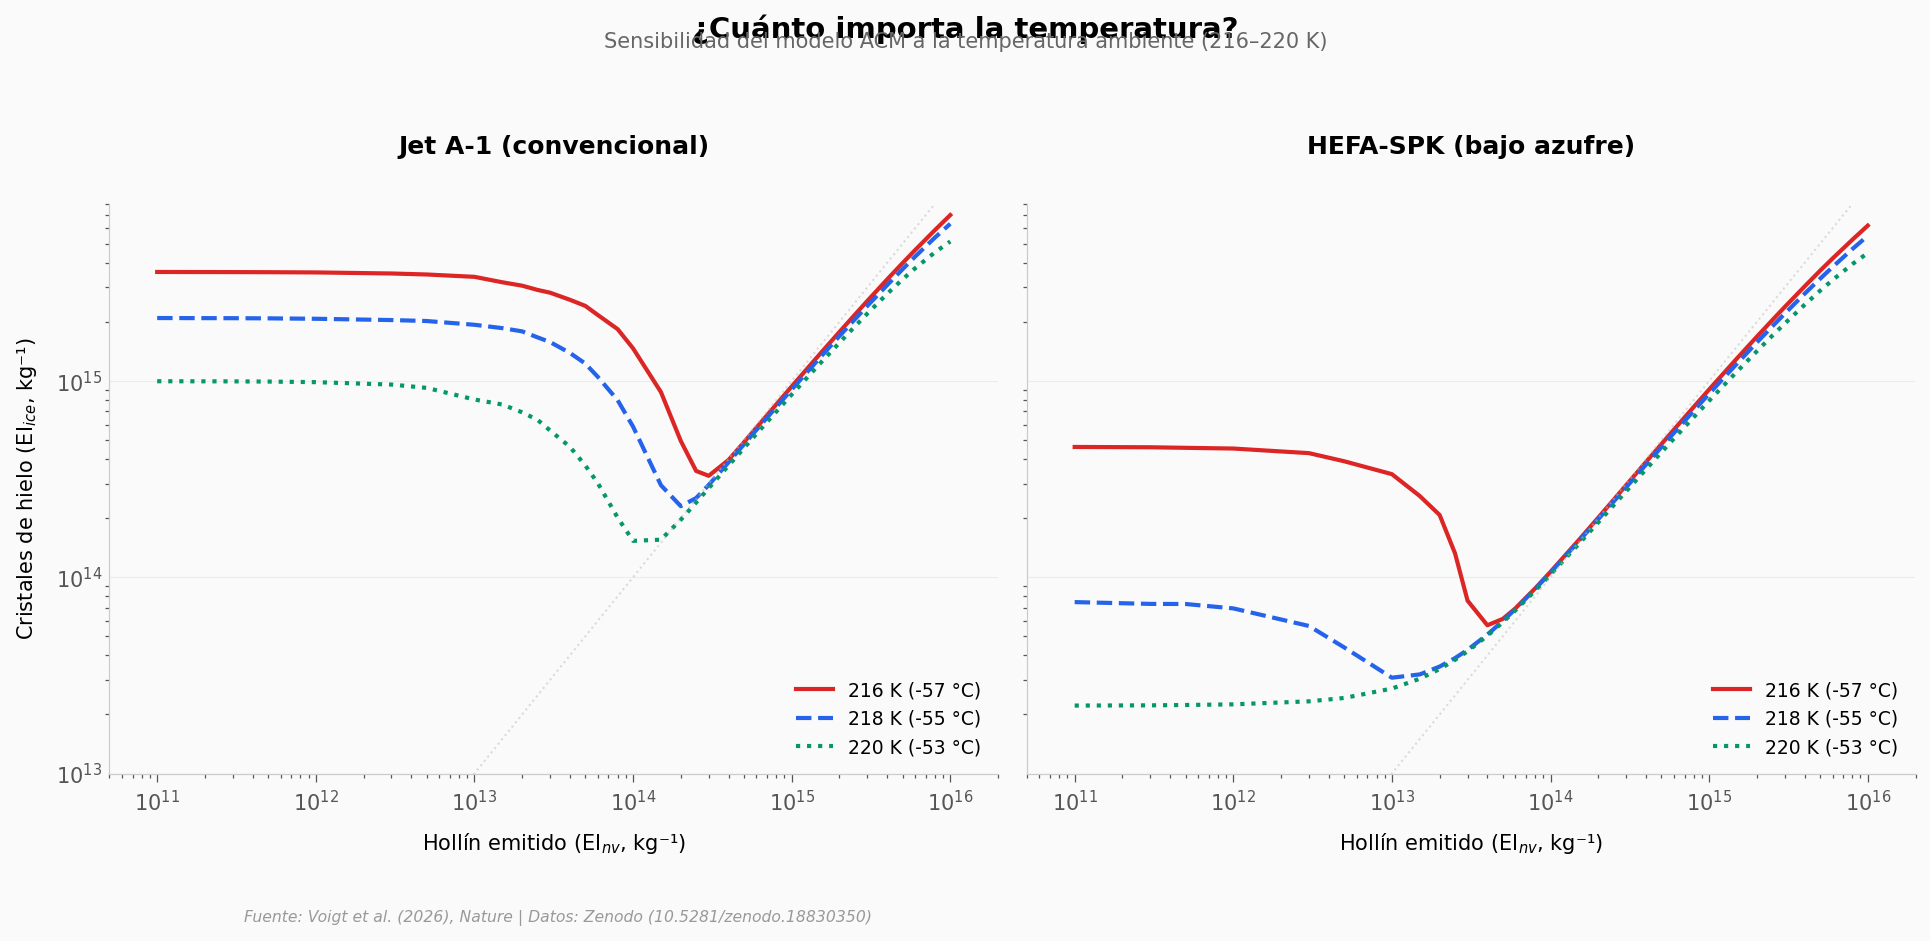

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True)

temp_colors = {216: COLOR_ALERTA, 218: COLOR_JETA1, 220: COLOR_HEFA}
temp_styles = {216: '-', 218: '--', 220: ':'}

for ax, fuel, title in [(ax1, 'Jet-A1', 'Jet A-1 (convencional)'), 
                          (ax2, 'SPK', 'HEFA-SPK (bajo azufre)')]:
    for temp in [216, 218, 220]:
        sub = df_temp[(df_temp['fuel'] == fuel) & (df_temp['temp_k'] == temp)].sort_values('soot_ei_kg')
        ax.plot(sub['soot_ei_kg'], sub['ice_ei_kg'], color=temp_colors[temp],
                linewidth=2, linestyle=temp_styles[temp],
                label=f'{temp} K ({temp - 273:.0f} °C)')
    
    # Línea 1:1
    ax.plot(x_11, x_11, color=COLOR_GRIS, linewidth=1, linestyle=':', alpha=0.5)
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Hollín emitido (EI$_{nv}$, kg⁻¹)', fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlim(5e10, 2e16)
    ax.set_ylim(1e13, 8e15)
    ax.legend(fontsize=9, loc='lower right', framealpha=0.9)

ax1.set_ylabel('Cristales de hielo (EI$_{ice}$, kg⁻¹)', fontsize=10)

fig.suptitle('¿Cuánto importa la temperatura?', fontsize=14, fontweight='bold', y=1.05)
fig.text(0.5, 1.01, 'Sensibilidad del modelo ACM a la temperatura ambiente (216–220 K)',
         ha='center', fontsize=10, color='#666666')

fig.text(0.13, -0.05, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/sensibilidad_temperatura.png', dpi=200, bbox_inches='tight')
plt.show()

### El doble golpe del biocombustible

A la izquierda, Jet A-1 convencional: aunque cambia la temperatura, los cristales se mantienen por encima de 10¹⁵ en el régimen lean-burn. A la derecha, HEFA-SPK: a 220 K los cristales caen a 2,2 × 10¹³ — unas 44 veces menos que el Jet A-1 a la misma temperatura.

El biocombustible bajo en azufre no solo elimina el hollín como semilla de cristales — también reduce las partículas volátiles de azufre que toman el relevo.

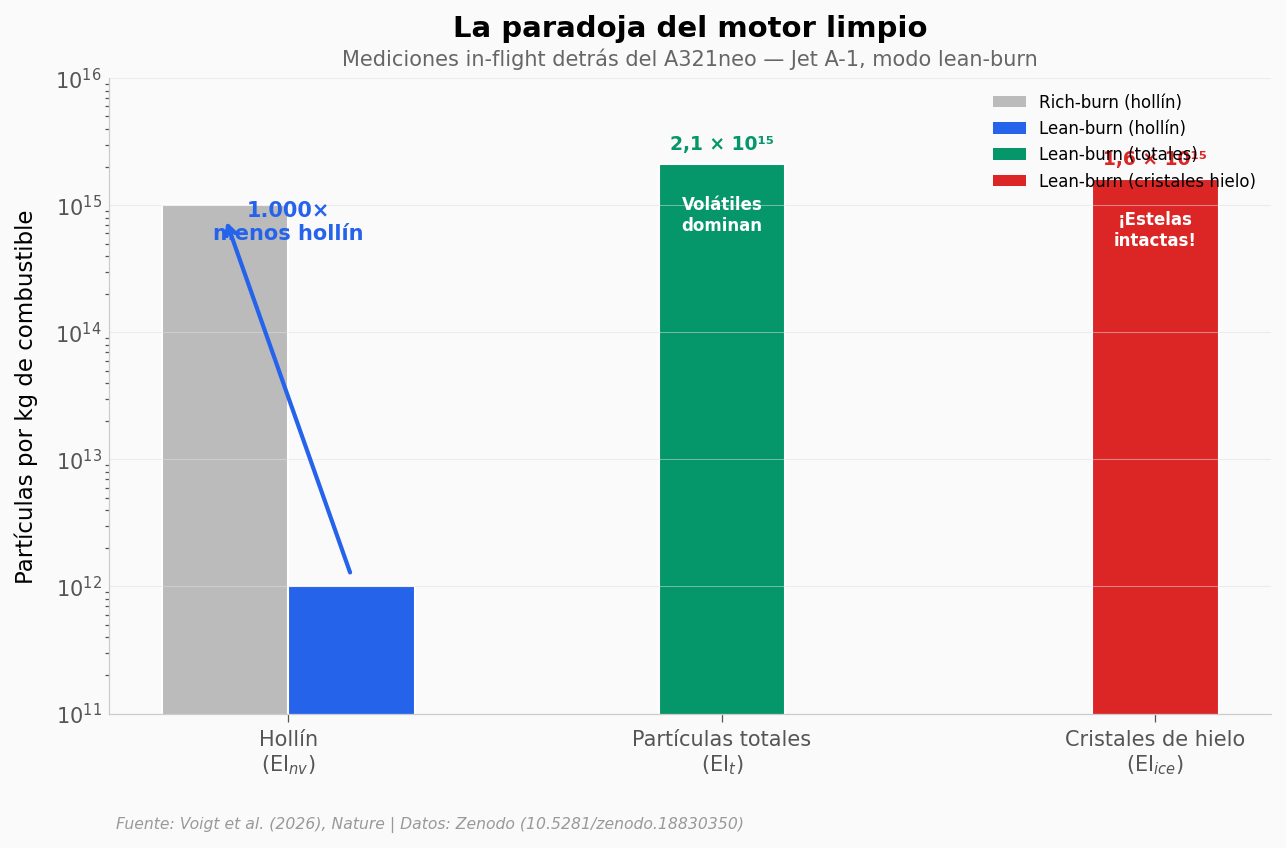

In [4]:
fig, ax = plt.subplots(figsize=(10, 5.5))

# Datos de medición + modelo para comparación de regímenes
categories = ['Hollín\n(EI$_{nv}$)', 'Partículas totales\n(EI$_t$)', 'Cristales de hielo\n(EI$_{ice}$)']
rich_vals = [EI_NV_RICH, None, None]  # Solo tenemos hollín para rich-burn
lean_vals = [EI_NV_LEAN, 2.1e15, EI_ICE_JETA1]

x = np.array([0, 1.2, 2.4])
width = 0.35

# Rich-burn solo hollín
ax.bar(x[0] - width/2, rich_vals[0], width, color=COLOR_GRIS, label='Rich-burn (convencional)',
       edgecolor='white', linewidth=1)
# Lean-burn
bars_lean = ax.bar([x[0] + width/2, x[1], x[2]], 
                    [lean_vals[0], lean_vals[1], lean_vals[2]], 
                    width, color=[COLOR_JETA1, COLOR_HEFA, COLOR_ALERTA],
                    edgecolor='white', linewidth=1)

# Anotaciones
ax.annotate(f'1.000×\nmenos hollín', xy=(x[0], 5e14), fontsize=10, fontweight='bold',
            color=COLOR_JETA1, ha='center', va='bottom')

ax.annotate('', xy=(x[0] - width/2, EI_NV_RICH * 0.8), xytext=(x[0] + width/2, EI_NV_LEAN * 1.2),
            arrowprops=dict(arrowstyle='->', color=COLOR_JETA1, lw=2))

ax.text(x[1], lean_vals[1] * 1.3, '2,1 × 10¹⁵', fontsize=9, fontweight='bold', 
        color=COLOR_HEFA, ha='center')
ax.text(x[1], lean_vals[1] * 0.3, 'Volátiles\ndominan', fontsize=8, color='white', 
        ha='center', fontweight='bold')

ax.text(x[2], lean_vals[2] * 1.3, '1,6 × 10¹⁵', fontsize=9, fontweight='bold',
        color=COLOR_ALERTA, ha='center')
ax.text(x[2], lean_vals[2] * 0.3, '¡Estelas\nintactas!', fontsize=8, color='white',
        ha='center', fontweight='bold')

ax.set_yscale('log')
ax.set_ylim(1e11, 1e16)
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=10)
ax.set_ylabel('Partículas por kg de combustible', fontsize=11)

ax.set_title('La paradoja del motor limpio', fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Mediciones in-flight detrás del A321neo — Jet A-1, modo lean-burn',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Leyenda manual
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=COLOR_GRIS, label='Rich-burn (hollín)'),
                   Patch(facecolor=COLOR_JETA1, label='Lean-burn (hollín)'),
                   Patch(facecolor=COLOR_HEFA, label='Lean-burn (totales)'),
                   Patch(facecolor=COLOR_ALERTA, label='Lean-burn (cristales hielo)')]
ax.legend(handles=legend_elements, fontsize=8, loc='upper right', framealpha=0.9)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/paradoja_motor_limpio.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿Cuánto ayuda cambiar el combustible?

El motor lean-burn eliminó el 99,9% del hollín — y las estelas siguieron. Pero el combustible bajo en azufre redujo los cristales de hielo 3,2 veces. ¿Cuánto se gana con cada nivel de pureza?

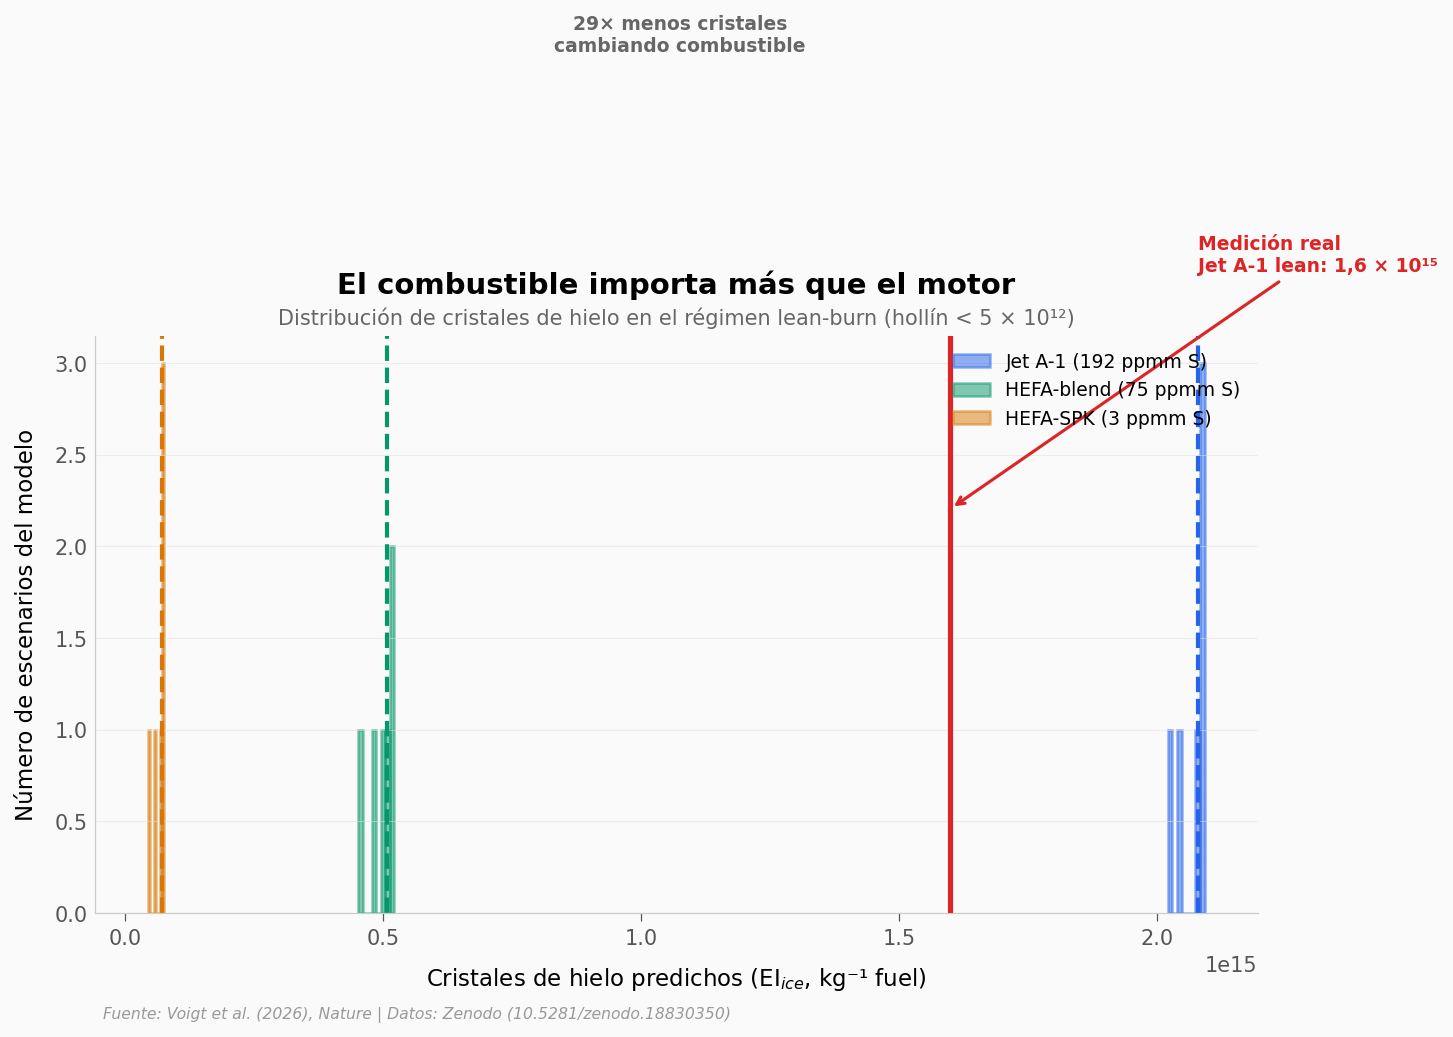

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

# Distribución de EI_ice en el régimen lean-burn (soot < 5e12) para cada combustible
for fuel, color, label, fsc in [
    ('Jet-A1_con2', COLOR_JETA1, 'Jet A-1 (192 ppmm S)', 192),
    ('HEFA_con2', COLOR_HEFA, 'HEFA-blend (75 ppmm S)', 75),
    ('HEFA', COLOR_SPK, 'HEFA-SPK (3 ppmm S)', 3.2)
]:
    sub = df_fuel[(df_fuel['fuel'] == fuel) & (df_fuel['soot_ei_kg'] <= 5e12)]
    ax.hist(sub['ice_ei_kg'], bins=8, color=color, alpha=0.5, edgecolor=color,
            linewidth=1.2, label=label)
    median = sub['ice_ei_kg'].median()
    ax.axvline(x=median, color=color, linewidth=2, linestyle='--')

# Medición real Jet A-1
ax.axvline(x=EI_ICE_JETA1, color=COLOR_ALERTA, linewidth=2.5, linestyle='-', zorder=5)
ax.annotate('Medición real\nJet A-1 lean: 1,6 × 10¹⁵',
            xy=(EI_ICE_JETA1, ax.get_ylim()[1] * 0.7 if ax.get_ylim()[1] > 0 else 3),
            xytext=(EI_ICE_JETA1 * 1.3, 3.5),
            fontsize=9, color=COLOR_ALERTA, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.5))

# Flecha bidireccional entre medianas
jet_med = df_fuel[(df_fuel['fuel'] == 'Jet-A1_con2') & (df_fuel['soot_ei_kg'] <= 5e12)]['ice_ei_kg'].median()
hefa_med = df_fuel[(df_fuel['fuel'] == 'HEFA') & (df_fuel['soot_ei_kg'] <= 5e12)]['ice_ei_kg'].median()
ax.annotate('', xy=(hefa_med, 4.5), xytext=(jet_med, 4.5),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ratio = jet_med / hefa_med
ax.text((jet_med + hefa_med) / 2, 4.7, f'{ratio:.0f}× menos cristales\ncambiando combustible',
        fontsize=9, color='#666666', ha='center', fontweight='bold')

ax.set_xlabel('Cristales de hielo predichos (EI$_{ice}$, kg⁻¹ fuel)', fontsize=11)
ax.set_ylabel('Número de escenarios del modelo', fontsize=11)
ax.set_title('El combustible importa más que el motor', fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Distribución de cristales de hielo en el régimen lean-burn (hollín < 5 × 10¹²)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(fontsize=9, loc='upper right', framealpha=0.9)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/distribucion_combustibles.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| Los motores lean-burn reducen el hollín 1.000× | ✅ | EI_nv: 10¹⁵ → 10¹² kg⁻¹ (mediana, rango 0,5–1,9 × 10¹²). 3 órdenes de magnitud confirmados |
| Las estelas siguen formándose con ~10¹⁵ cristales/kg | ✅ | EI_ice = 1,6 (±0,3) × 10¹⁵ (media) en lean-burn con Jet A-1 — comparable al nivel rich-burn |
| Los cristales nuclean sobre partículas volátiles, no sobre hollín | ✅ | Ratio hielo/hollín = 1.600× en lean-burn; partículas totales (d > 5 nm) = 2,1 × 10¹⁵ dominadas por volátiles |
| El combustible bajo en azufre reduce los cristales ~3× | ✅ | EI_ice HEFA-blend (75 ppmm S) = 0,5 (±0,2) × 10¹⁵ (media) vs 1,6 × 10¹⁵ para Jet A-1 → 3,2× |
| Los motores lean-burn no reducen el efecto de calentamiento de las estelas | ⚠️ | Los datos sugieren que por sí solos no son suficientes (el paper usa *indicate* y *suggesting*). Se necesitan cambios en el combustible y en la arquitectura de venteo del aceite lubricante |

> **Limitaciones:** (1) Mediciones detrás de un solo modelo de motor (LEAP-1A). (2) Modo rich-burn forzado por FADEC — no refleja operación normal. (3) Las curvas ACM son un modelo teórico; las mediciones reales son un solo punto por condición. (4) Los valores HEFA-SPK puros vienen solo del modelo — no hay medición in-flight para ese combustible.

## Ahora tú

1. **¿Cuánto importan esos 4 grados?** Cambia `temp` en la celda de abajo para comparar 216 K vs 220 K — ¿a cuántos cristales de hielo equivale un día más frío a altitud de crucero?

2. **¿Existe un umbral de azufre?** Las curvas del modelo tienen 3 niveles de azufre (192, 75, 3 ppmm). ¿La relación es lineal o hay un salto brusco? Prueba a graficar azufre vs cristales de hielo a un nivel fijo de hollín.

3. **¿Qué pasa con tráfico aéreo 2–3× mayor?** Si en 2050 se duplican los vuelos pero todos usan biocombustible bajo en azufre, ¿las estelas totales bajan o suben?

In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿Cuánto importan esos 4 grados? Comparemos Jet A-1 a dos temperaturas extremas

temp_fria = 216  # K — día más frío
temp_calida = 220  # K — día más cálido
soot_leanburn = 1e12  # Hollín típico lean-burn

for temp in [temp_fria, temp_calida]:
    sub = df_temp[(df_temp['fuel'] == 'Jet-A1') & (df_temp['temp_k'] == temp)]
    # Interpolación log-log para encontrar ice @ soot dado
    from scipy import interpolate
    f_interp = interpolate.interp1d(np.log10(sub['soot_ei_kg']), np.log10(sub['ice_ei_kg']),
                                     kind='linear', fill_value='extrapolate')
    ice_at_soot = 10 ** f_interp(np.log10(soot_leanburn))
    print(f"Jet A-1 @ {temp} K ({temp-273:.0f} °C): {ice_at_soot:.2e} cristales/kg")

# Ratio
sub_216 = df_temp[(df_temp['fuel'] == 'Jet-A1') & (df_temp['temp_k'] == temp_fria)]
sub_220 = df_temp[(df_temp['fuel'] == 'Jet-A1') & (df_temp['temp_k'] == temp_calida)]
f_216 = interpolate.interp1d(np.log10(sub_216['soot_ei_kg']), np.log10(sub_216['ice_ei_kg']),
                              kind='linear', fill_value='extrapolate')
f_220 = interpolate.interp1d(np.log10(sub_220['soot_ei_kg']), np.log10(sub_220['ice_ei_kg']),
                              kind='linear', fill_value='extrapolate')
ice_216 = 10 ** f_216(np.log10(soot_leanburn))
ice_220 = 10 ** f_220(np.log10(soot_leanburn))
print(f"\nRatio 216K/220K: {ice_216/ice_220:.1f}× más cristales en un día 4° más frío")
print(f"Eso equivale a pasar de {ice_220:.1e} a {ice_216:.1e} cristales por kg de combustible")

Jet A-1 @ 216 K (-57 °C): 3.57e+15 cristales/kg
Jet A-1 @ 220 K (-53 °C): 9.87e+14 cristales/kg

Ratio 216K/220K: 3.6× más cristales en un día 4° más frío
Eso equivale a pasar de 9.9e+14 a 3.6e+15 cristales por kg de combustible


---

## Créditos

- **Paper:** Voigt, C. et al. *Substantial aircraft contrail formation at low soot emission levels*. Nature (2026). DOI: [10.1038/s41586-026-10286-0](https://doi.org/10.1038/s41586-026-10286-0)
- **Datos:** Simulaciones ACM publicadas en [Zenodo](https://doi.org/10.5281/zenodo.18830350). Mediciones in-flight del DLR ([HALO-DB](https://halo-db.pa.op.dlr.de/))
- **Licencia datos:** CC BY 4.0
- **Notebook:** [Ciencia a Mordiscos — El Lab](https://cienciaamordiscos.com)
- **Código:** [GitHub](https://github.com/Ciencia-a-Mordiscos/lab/tree/main/papers/2026-04-04-estelas-avion-motor-bajo-hollin)